# Week 3 Lab — Stream Preprocessing, Windows & Summarization

**Data Stream Mining — NOVA IMS**  
**LU2 — Data Preprocessing in Streams**  
**Estimated laboratory time: 1h15**

> ## Big Question
> **How can we represent data that we cannot store forever?**

Last week we learned to update statistics without storing the complete stream. This week we make a harder design decision: **which part of the past should our state represent?**

### Today we will build

`stream → window → online statistics → filtering / sampling → memory comparison`

### Learning objectives

By the end of the lab, you should be able to:
- explain landmark, sliding, and tumbling windows in operational terms;
- implement **instance-based** and **time-based** windows;
- maintain exact statistics over a sliding window;
- observe the **reactivity–stability** effect of window size;
- compare moving mean and moving median under injected noise;
- explain how a fixed window and a reservoir impose explicit memory budgets.

> **Pedagogical rule:** *First understand the update loop. Then use the framework.*

## 0. Setup & framing — ~5 min

We will use a deterministic synthetic stream so that every group sees the same regime change, noise pattern, and timestamps. **No internet connection is required.**

We will deliberately separate:

- **algorithmic state** — what the stream processor needs to keep;
- **visualization history** — what we temporarily record only so we can draw teaching plots.

In [1]:
from __future__ import annotations

from collections import deque
from datetime import datetime, timedelta
import math
import random
import statistics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

print("Environment ready.")

Environment ready.


### A reminder from Week 2

For a global running statistic, old raw observations can disappear while a compact state remains:

$
\text{old state} + x_t \rightarrow \text{new state}
$

For a sliding window, we need a second operation:

$
\text{new state}=\operatorname{Add}(\operatorname{Remove}(\text{old state},x_{t-w}),x_t)
$

That is the computational meaning of **controlled forgetting**.

## 1. One stream, different memories — ~7 min

We start with a realistic sensor-like stream. The first half operates around one level; halfway through, the system changes regime. We also add ordinary measurement noise.

The raw history is useful for teaching, but imagine that the observations are actually arriving one at a time.

In [2]:
def make_stream(n=600, seed=42, change_at=300):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    baseline = 100 + 2.5 * np.sin(2 * np.pi * t / 60)
    shift = np.where(t < change_at, 0.0, 18.0)
    noise_scale = np.where(t < change_at, 1.8, 3.2)
    values = baseline + shift + rng.normal(0, noise_scale)
    timestamps = pd.date_range("2026-01-01 08:00:00", periods=n, freq="min")
    regime = np.where(t < change_at, "before", "after")
    return pd.DataFrame({"timestamp": timestamps, "value": values, "regime": regime})

stream_df = make_stream()
stream_df.head()

,timestamp,value,regime
0,2026-01-01 08:00:00,100.548491,before
1,2026-01-01 08:01:00,98.389350,before
2,2026-01-01 08:02:00,101.870591,before
3,2026-01-01 08:03:00,102.465559,before
4,2026-01-01 08:04:00,97.504978,before


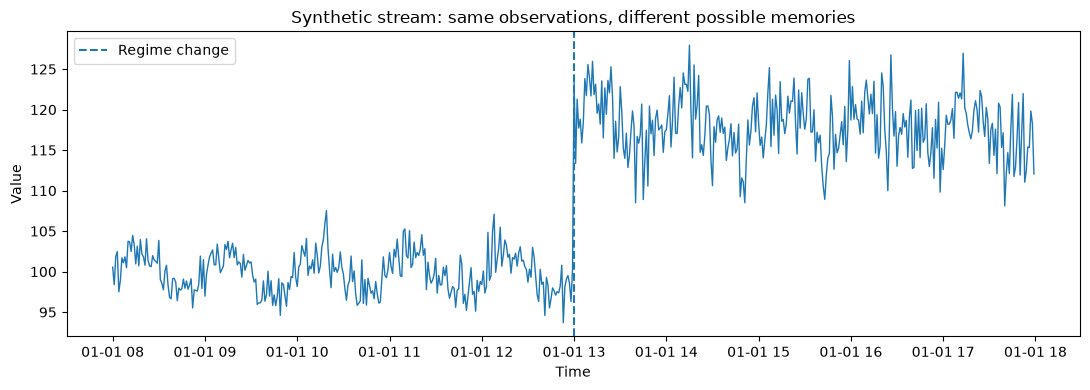

In [3]:
plt.figure(figsize=(11, 4))
plt.plot(stream_df["timestamp"], stream_df["value"], linewidth=1)
plt.axvline(stream_df.loc[300, "timestamp"], linestyle="--", label="Regime change")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Synthetic stream: same observations, different possible memories")
plt.legend()
plt.tight_layout()
plt.show()

### Think before coding

Suppose the stream has been running for one year. Which of these descriptions might an application need?

- everything since the system started;
- only the last 50 events;
- only the last 30 minutes;
- one summary for every hour;
- a small representative sample.

**The data source can be identical. The memory policy is different.**

## 2. Landmark, sliding & tumbling windows — ~13 min

We first use a tiny sequence so that we can *see* what enters and leaves.

### 2.1 Landmark-style memory

A landmark window retains everything after a reference point. Its main limitation is easy to see: unless a new landmark resets the process, its memory grows.

In [4]:
toy = [4, 7, 3, 6, 5, 9]
landmark = []

for x in toy:
    landmark.append(x)
    print(f"new={x:>2}  landmark={landmark}")

new= 4  landmark=[4]
new= 7  landmark=[4, 7]
new= 3  landmark=[4, 7, 3]
new= 6  landmark=[4, 7, 3, 6]
new= 5  landmark=[4, 7, 3, 6, 5]
new= 9  landmark=[4, 7, 3, 6, 5, 9]


### 2.2 Fixed-size sliding window

A `deque` is a natural data structure for a fixed-size window: new values enter on one side and expired values leave from the other.

In [5]:
window = deque(maxlen=3)
for x in toy:
    before = list(window)
    expired = before[0] if len(before) == window.maxlen else None
    window.append(x)
    print(f"new={x:>2}  expired={str(expired):>4}  active={list(window)}")

new= 4  expired=None  active=[4]
new= 7  expired=None  active=[4, 7]
new= 3  expired=None  active=[4, 7, 3]
new= 6  expired=   4  active=[7, 3, 6]
new= 5  expired=   7  active=[3, 6, 5]
new= 9  expired=   3  active=[6, 5, 9]


### 2.3 Tumbling windows

A tumbling window is different: observations are collected into **non-overlapping blocks**. Once a block closes, we can emit a summary and forget the raw block.

In [18]:
def tumbling_by_count(values, block_size):
    block = []
    emitted = []
    for x in values:
        block.append(float(x))
        if len(block) == block_size:
            emitted.append({
                "count": len(block),
                "mean": float(np.mean(block)),
                "min": min(block),
                "max": max(block),
            })
            block = []
    if block:  # partial final block for demonstration
        emitted.append({
            "count": len(block),
            "mean": float(np.mean(block)),
            "min": min(block),
            "max": max(block),
        })
    return emitted

tumbling_by_count(toy, block_size=2)

[{'count': 2, 'mean': 5.5, 'min': 4.0, 'max': 7.0},
 {'count': 2, 'mean': 4.5, 'min': 3.0, 'max': 6.0},
 {'count': 2, 'mean': 7.0, 'min': 5.0, 'max': 9.0}]

### Quick comparison

| Representation | What remains active? | What happens to old raw observations? |
|---|---|---|
| Landmark | Everything since landmark | Kept until reset |
| Sliding | Only recent window | Expired continuously |
| Tumbling | Current block | Previous block can disappear after summary |

> **Windowing is controlled forgetting.**

## 3. Instance-based vs time-based windows — ~10 min

With perfectly regular arrivals, “last 30 observations” can look similar to “last 30 minutes”. Real streams may be irregular, so these definitions can diverge.

We create an irregular copy by deliberately removing some timestamps from our teaching stream.

In [19]:
irregular_df = stream_df.iloc[:90].copy()
irregular_df = irregular_df.loc[((np.arange(len(irregular_df)) + 1) % 5) != 0].reset_index(drop=True)

print("Regular observations:", 90)
print("Irregular observations:", len(irregular_df))
print("Largest time gap (minutes):",
      irregular_df["timestamp"].diff().dt.total_seconds().max() / 60)

Regular observations: 90
Irregular observations: 72
Largest time gap (minutes): 2.0


In [20]:
class TimeSlidingWindow:
    def __init__(self, duration):
        self.duration = duration
        self.events = deque()

    def append(self, timestamp, value):
        self.events.append((timestamp, float(value)))
        cutoff = timestamp - self.duration
        while self.events and self.events[0][0] < cutoff:
            self.events.popleft()

    @property
    def values(self):
        return [x for _, x in self.events]

    @property
    def timestamps(self):
        return [t for t, _ in self.events]

instance_window = deque(maxlen=10)
time_window = TimeSlidingWindow(timedelta(minutes=10))

for row in irregular_df.itertuples(index=False):
    instance_window.append(float(row.value))
    time_window.append(row.timestamp, row.value)

print("Instance-based window: last 10 observations")
print("  retained values:", len(instance_window))
print("Time-based window: last 10 minutes")
print("  retained values:", len(time_window.values))
print("  from", time_window.timestamps[0], "to", time_window.timestamps[-1])

Instance-based window: last 10 observations
  retained values: 10
Time-based window: last 10 minutes
  retained values: 9
  from 2026-01-01 09:18:00 to 2026-01-01 09:28:00


### Exercise 1 — Change the clock

Change the time-based window from **10 minutes** to **20 minutes**. How many observations remain? Is that necessarily 20?

<details>
<summary><strong>Show one possible solution</strong></summary>

```python
w20 = TimeSlidingWindow(timedelta(minutes=20))
for row in irregular_df.itertuples(index=False):
    w20.append(row.timestamp, row.value)
print(len(w20.values))
```

The answer depends on which timestamps are present. A time window measures **elapsed time**, not row count.
</details>

## 4. Exact statistics over a sliding window — ~15 min

For a fixed-size exact window, we can update the sum when one observation enters and another leaves:

$
S_t = S_{t-1} + x_t - x_{t-w}
$

For teaching, we will maintain both \(\sum x\) and \(\sum x^2\). Then the sample variance inside the *current window* is

$
s^2 = \frac{\sum x_i^2 - (\sum x_i)^2/n}{n-1}, \qquad n>1.
$

**Important:** this is an intuitive exact-window implementation. In production systems, numerical stability deserves explicit attention.

In [9]:
class InstanceSlidingWindow:
    def __init__(self, size):
        if size <= 0:
            raise ValueError("size must be positive")
        self.size = int(size)
        self.data = deque()
        self.sum = 0.0
        self.sum_sq = 0.0

    def append(self, value):
        x = float(value)
        expired = None
        if len(self.data) == self.size:
            expired = self.data.popleft()
            self.sum -= expired
            self.sum_sq -= expired * expired
        self.data.append(x)
        self.sum += x
        self.sum_sq += x * x
        return expired

    @property
    def count(self):
        return len(self.data)

    @property
    def mean(self):
        return self.sum / self.count if self.count else float("nan")

    @property
    def variance(self):
        n = self.count
        if n < 2:
            return float("nan")
        numerator = self.sum_sq - (self.sum * self.sum) / n
        return max(0.0, numerator / (n - 1))

    @property
    def std(self):
        return math.sqrt(self.variance) if self.count >= 2 else float("nan")

    @property
    def values(self):
        return list(self.data)

In [10]:
w = InstanceSlidingWindow(size=5)
print("value | expired | active window        | mean   | std")
print("-" * 65)
for x in [4, 7, 3, 6, 5, 9, 2]:
    expired = w.append(x)
    print(f"{x:>5} | {str(expired):>7} | {str(w.values):<20} | {w.mean:>6.2f} | {w.std:>6.2f}")

value | expired | active window        | mean   | std
-----------------------------------------------------------------
    4 |    None | [4.0]                |   4.00 |    nan
    7 |    None | [4.0, 7.0]           |   5.50 |   2.12
    3 |    None | [4.0, 7.0, 3.0]      |   4.67 |   2.08
    6 |    None | [4.0, 7.0, 3.0, 6.0] |   5.00 |   1.83
    5 |    None | [4.0, 7.0, 3.0, 6.0, 5.0] |   5.00 |   1.58
    9 |     4.0 | [7.0, 3.0, 6.0, 5.0, 9.0] |   6.00 |   2.24
    2 |     7.0 | [3.0, 6.0, 5.0, 9.0, 2.0] |   5.00 |   2.74


### Validate the current window — not the whole history

Batch calculations are useful **after the update** as a trusted check. They are not the streaming algorithm.

In [11]:
current = np.asarray(w.values)
print("Online/window mean:", w.mean)
print("NumPy check:       ", current.mean())
print("Online/window var: ", w.variance)
print("NumPy check:       ", current.var(ddof=1))

assert np.isclose(w.mean, current.mean())
assert np.isclose(w.variance, current.var(ddof=1))
print("Validation passed.")

Online/window mean: 5.0
NumPy check:        5.0
Online/window var:  7.5
NumPy check:        7.5
Validation passed.


### Exercise 2 — Predict before running

For a window of size 3, process `[10, 20, 30, 40]`.

1. What should the final active window be?
2. What should its mean be?
3. Which observation expires when `40` arrives?

<details>
<summary><strong>Show solution</strong></summary>

Final window: `[20, 30, 40]`  
Mean: `30`  
Expired value: `10`

```python
check = InstanceSlidingWindow(3)
for x in [10, 20, 30, 40]:
    expired = check.append(x)
print(check.values, check.mean, expired)
```
</details>

## 5. Window size: reactivity vs stability — ~10 min

Now we apply different memories to the **same stream**.

We compare:
- a global running mean;
- `w = 10` — short memory;
- `w = 50` — medium memory;
- `w = 200` — longer memory.

Watch what happens at the regime change.

In [12]:
def running_mean_trace(values):
    n = 0
    mean = 0.0
    out = []
    for x in values:
        n += 1
        mean += (float(x) - mean) / n
        out.append(mean)
    return out


def sliding_mean_trace(values, size):
    window = InstanceSlidingWindow(size)
    out = []
    for x in values:
        window.append(x)
        out.append(window.mean)
    return out

values = stream_df["value"].to_numpy()
stream_df["global_mean"] = running_mean_trace(values)
for size in [10, 50, 200]:
    stream_df[f"mean_w{size}"] = sliding_mean_trace(values, size)

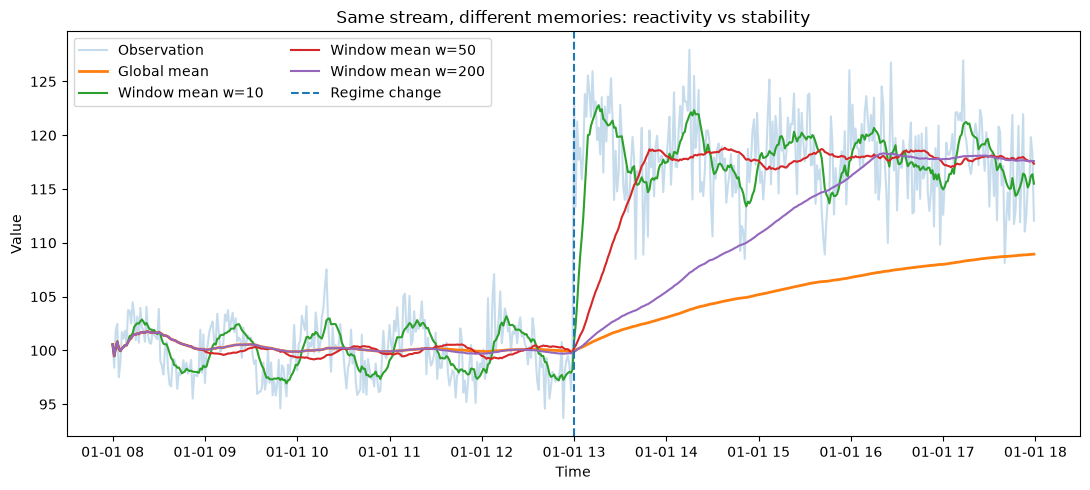

In [13]:
plt.figure(figsize=(11, 5))
plt.plot(stream_df["timestamp"], stream_df["value"], alpha=0.25, label="Observation")
plt.plot(stream_df["timestamp"], stream_df["global_mean"], linewidth=2, label="Global mean")
for size in [10, 50, 200]:
    plt.plot(stream_df["timestamp"], stream_df[f"mean_w{size}"], label=f"Window mean w={size}")
plt.axvline(stream_df.loc[300, "timestamp"], linestyle="--", label="Regime change")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Same stream, different memories: reactivity vs stability")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

### Discuss

- Which window reacts fastest after the change?
- Which estimate is smoothest before the change?
- Why does the global mean remain far from the new regime for so long?

> **Window size is not just a technical parameter. It changes what “current behaviour” means.**

### Exercise 3 — Choose your own memory

Try `w=25` or `w=100`. Before plotting, predict where its curve should lie relative to `w=10`, `w=50`, and `w=200`.

<details>
<summary><strong>Show code pattern</strong></summary>

```python
stream_df["mean_w25"] = sliding_mean_trace(values, 25)
plt.plot(stream_df["timestamp"], stream_df["mean_w25"])
```

Interpretation matters more than the exact curve: smaller windows should normally react faster but fluctuate more.
</details>

## 6. Noise introduction & filtering — ~8 min

A real stream can contain unusual measurements. For this experiment we **inject synthetic spikes into a copy** of the stream.

This does **not** mean the original source was wrong. We are deliberately corrupting a teaching copy so we can compare filters.

In [14]:
def inject_spikes(values, n_spikes=8, magnitude=25.0, seed=42):
    arr = np.asarray(values, dtype=float).copy()
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(arr), size=n_spikes, replace=False)
    signs = rng.choice([-1.0, 1.0], size=n_spikes)
    arr[idx] += signs * magnitude
    return arr, np.sort(idx)

noisy_values, spike_idx = inject_spikes(values, n_spikes=8, magnitude=25, seed=SEED)
print("Synthetic spike positions:", spike_idx.tolist())

Synthetic spike positions: [51, 52, 258, 261, 389, 418, 459, 513]


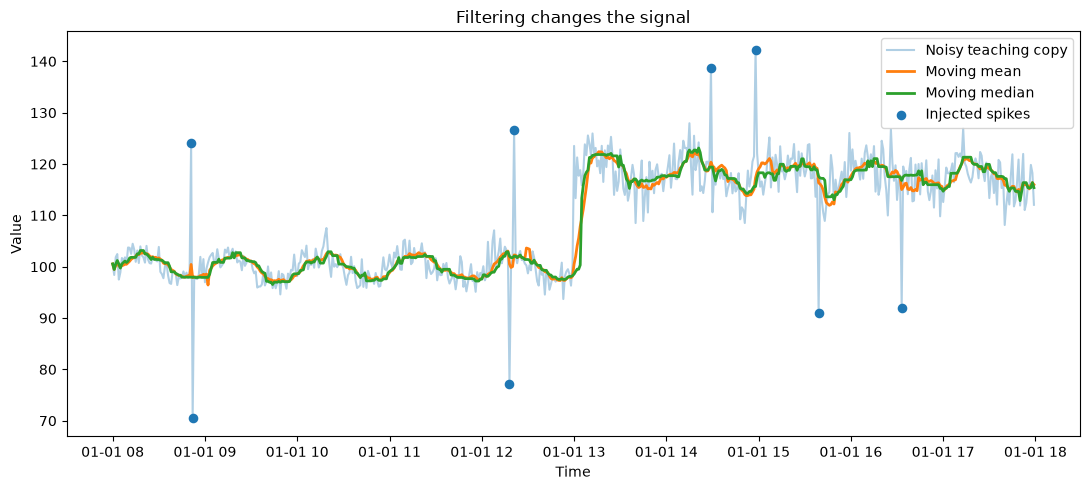

In [15]:
def moving_median_trace(values, size):
    q = deque(maxlen=size)
    out = []
    for x in values:
        q.append(float(x))
        out.append(float(statistics.median(q)))
    return out

filter_size = 11
mean_filtered = sliding_mean_trace(noisy_values, filter_size)
median_filtered = moving_median_trace(noisy_values, filter_size)

plt.figure(figsize=(11, 5))
plt.plot(stream_df["timestamp"], noisy_values, alpha=0.35, label="Noisy teaching copy")
plt.plot(stream_df["timestamp"], mean_filtered, linewidth=2, label="Moving mean")
plt.plot(stream_df["timestamp"], median_filtered, linewidth=2, label="Moving median")
plt.scatter(stream_df.loc[spike_idx, "timestamp"], noisy_values[spike_idx], s=35, label="Injected spikes")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Filtering changes the signal")
plt.legend()
plt.tight_layout()
plt.show()

### The important question

> **Did we remove noise — or did we remove information?**

A median filter can be more robust to isolated spikes than a mean, but neither filter can know by itself whether a spike is an error, a rare event, or the anomaly we actually care about.

**Cleaning and anomaly removal are not the same decision.**

## 7. Memory restrictions & reservoir sampling — ~5 min

Three representations can process the same number of observations while retaining very different amounts of raw history:

- **full history** grows with the stream;
- **sliding window** is bounded by `w`;
- **reservoir sample** is bounded by `k` and keeps a random sample of everything seen so far.

In [16]:
class ReservoirSampler:
    def __init__(self, k, seed=42):
        self.k = int(k)
        self.rng = random.Random(seed)
        self.sample = []
        self.n_seen = 0

    def update(self, item):
        self.n_seen += 1
        if len(self.sample) < self.k:
            self.sample.append(item)
        else:
            j = self.rng.randint(1, self.n_seen)
            if j <= self.k:
                self.sample[j - 1] = item

full_history = []
sliding = deque(maxlen=50)
reservoir = ReservoirSampler(k=30, seed=SEED)

checkpoints = {1, 10, 50, 100, 300, 600}
rows = []
for i, x in enumerate(values, start=1):
    full_history.append(float(x))
    sliding.append(float(x))
    reservoir.update(float(x))
    if i in checkpoints:
        rows.append({
            "processed": i,
            "full_history_retained": len(full_history),
            "sliding_retained": len(sliding),
            "reservoir_retained": len(reservoir.sample),
        })

memory_df = pd.DataFrame(rows)
memory_df

,processed,full_history_retained,sliding_retained,reservoir_retained
0,1,1,1,1
1,10,10,10,10
2,50,50,50,30
3,100,100,50,30
4,300,300,50,30
5,600,600,50,30


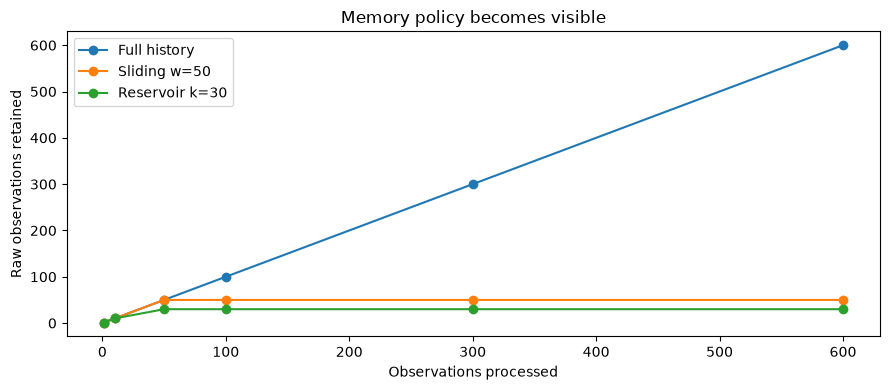

In [21]:
plt.figure(figsize=(9, 4))
plt.plot(memory_df["processed"], memory_df["full_history_retained"], marker="o", label="Full history")
plt.plot(memory_df["processed"], memory_df["sliding_retained"], marker="o", label="Sliding w=50")
plt.plot(memory_df["processed"], memory_df["reservoir_retained"], marker="o", label="Reservoir k=30")
plt.xlabel("Observations processed")
plt.ylabel("Raw observations retained")
plt.title("Memory policy becomes visible")
plt.legend()
plt.tight_layout()
plt.show()

### Optional mini-experiment

Change `k=30` to `k=10` or `k=100`.

- Does the memory grow after the reservoir becomes full?
- What changes when `k` increases?
- What does the reservoir remember that a mean alone cannot?

## 8. Reflection & Week 4 bridge — ~2 min

For each representation, ask three questions:

| Representation | What did it remember? | What did it forget? | What did it approximate? |
|---|---|---|---|
| Landmark | History since landmark | Before landmark | Nothing necessarily |
| Sliding | Recent exact observations | Expired history | Nothing necessarily |
| Tumbling summary | Block-level statistics | Raw closed block | Depends on summary |
| Reservoir | Selected raw observations | Most raw history | Full distribution/history |
| Filter | Smoothed signal | Fine detail / extremes | Underlying signal |

### Final takeaway

> # **Windowing is controlled forgetting.**

The right representation depends on the question the system needs to answer.

### Looking ahead — Week 4

So far we have learned how to **represent** a stream. Next we ask:

> **How can we evaluate a predictive model while the stream keeps moving?**

---
## References

- Babcock, B., Babu, S., Datar, M., Motwani, R., & Widom, J. (2002). *Models and Issues in Data Stream Systems.* PODS.
- Babcock, B., Datar, M., & Motwani, R. (2002). *Sampling from a Moving Window over Streaming Data.* SODA.
- Datar, M., Gionis, A., Indyk, P., & Motwani, R. (2002). *Maintaining Stream Statistics over Sliding Windows.* SIAM Journal on Computing, 31(6), 1794–1813.
- Vitter, J. S. (1985). *Random Sampling with a Reservoir.* ACM Transactions on Mathematical Software, 11(1), 37–57.
- Jeffery, S. R., Alonso, G., Franklin, M. J., Hong, W., & Widom, J. (2006). *A Pipelined Framework for Online Cleaning of Sensor Data Streams.* ICDE.
- Welford, B. P. (1962). *Note on a Method for Calculating Corrected Sums of Squares and Products.* Technometrics, 4(3), 419–420.